In [12]:
import os
import re
import warnings

import numpy as np
import pandas as pd

# -------------------------------------------------------------------
# CONFIG
# -------------------------------------------------------------------
BASE_DIR = "walk_segmented_csvs"  # folder containing trial CSVs
GAZE_COL = "gaze angle [deg]"

# RQA parameters
EPSILON = 2.0        # radius in degrees (same epsilon you use for plots)
L_MIN = 2            # minimum diagonal line length for DET, MaxL, ENT

# -------------------------------------------------------------------
# HELPER: filename parsing
# -------------------------------------------------------------------
def parse_filename(fname):
    """
    Parse trial info from a filename like:
    'Subject-03_Hill-Condition_Trial-01_Walk-Dir-Up.csv'
    
    Returns:
        dict with keys:
            'subject_number' (int or None)
            'condition' (str or None)  # e.g., 'Hill', 'Stair'
            'trial_number' (int or None)
            'walking_direction' (str or None)  # e.g., 'Up', 'Down'
    """
    name = os.path.splitext(os.path.basename(fname))[0]

    # Subject number
    m_sub = re.search(r"Subject-(\d+)", name, flags=re.IGNORECASE)
    subject_number = int(m_sub.group(1)) if m_sub else None

    # Condition (word before '-Condition')
    m_cond = re.search(r"([A-Za-z]+)-Condition", name, flags=re.IGNORECASE)
    condition = m_cond.group(1).capitalize() if m_cond else None

    # Trial number
    m_trial = re.search(r"Trial-(\d+)", name, flags=re.IGNORECASE)
    trial_number = int(m_trial.group(1)) if m_trial else None

    # Walking direction (from 'Walk-Dir-XYZ')
    m_dir = re.search(r"Walk-Dir-([A-Za-z]+)", name, flags=re.IGNORECASE)
    walking_direction = m_dir.group(1).capitalize() if m_dir else None

    if any(v is None for v in [subject_number, condition, trial_number, walking_direction]):
        warnings.warn(
            f"Could not fully parse filename '{fname}'. "
            f"Parsed values: subject={subject_number}, condition={condition}, "
            f"trial={trial_number}, direction={walking_direction}"
        )

    return {
        "subject_number": subject_number,
        "condition": condition,
        "trial_number": trial_number,
        "walking_direction": walking_direction,
    }

# -------------------------------------------------------------------
# HELPER: RQA line-length extraction
# -------------------------------------------------------------------
def _line_lengths_from_binary_array(arr, l_min):
    """
    Given a 1D boolean array, returns a list of lengths of contiguous
    True segments with length >= l_min.
    """
    lengths = []
    current = 0
    for val in arr:
        if val:
            current += 1
        else:
            if current >= l_min:
                lengths.append(current)
            current = 0
    if current >= l_min:
        lengths.append(current)
    return lengths

# -------------------------------------------------------------------
# HELPER: recurrence matrix + RQA computation
# -------------------------------------------------------------------
def recurrence_matrix_1d(x, epsilon):
    """
    Build a 1D recurrence matrix for time series x.

    Returns:
        R : (N, N) boolean array where R[i, j] is True
            if |x_i - x_j| <= epsilon.
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]  # drop NaNs here; x must already be cleaned elsewhere
    if x.size < 2:
        return np.zeros((0, 0), dtype=bool)

    dist = np.abs(x[:, None] - x[None, :])
    R = dist <= epsilon
    return R


def compute_rqa(x, epsilon, l_min=2):
    """
    Compute RQA measures (RR, DET, MaxL, ENT) for a 1D time series x
    with a given epsilon (radius).

    - Uses a 1D phase space (no embedding).
    - Recurrence if |x_i - x_j| <= epsilon.
    - RR: recurrence rate
    - DET: determinism (fraction of recurrence points in diagonal lines)
    - MaxL: max diagonal line length
    - ENT: Shannon entropy (base 2) of diagonal length distribution.
    """
    x = np.asarray(x, float)
    x = x[~np.isnan(x)]
    if x.size < 2:
        return np.nan, np.nan, np.nan, np.nan

    R = recurrence_matrix_1d(x, epsilon=epsilon)
    N = x.size

    # Remove main diagonal (self-recurrence)
    if R.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    np.fill_diagonal(R, False)

    total_points = R.size
    total_rec_points = R.sum()

    if total_rec_points == 0:
        return 0.0, 0.0, 0.0, 0.0

    # Recurrence rate
    RR = total_rec_points / total_points

    # Diagonal line statistics
    line_lengths = []
    for k in range(-N + 1, N):
        diag = np.diagonal(R, offset=k)
        if diag.size == 0:
            continue
        line_lengths.extend(_line_lengths_from_binary_array(diag, l_min))

    if not line_lengths:
        # No diagonal lines of length >= l_min
        DET = 0.0
        MaxL = 0.0
        ENT = 0.0
    else:
        # Determinism = fraction of recurrence points in diagonal lines
        points_in_lines = sum(line_lengths)
        DET = points_in_lines / total_rec_points

        MaxL = float(max(line_lengths))

        # Shannon entropy of line length distribution
        unique, counts = np.unique(line_lengths, return_counts=True)
        p = counts / counts.sum()
        ENT = float(-np.sum(p * np.log2(p)))

    return float(RR), float(DET), float(MaxL), float(ENT)

# -------------------------------------------------------------------
# MAIN: build summary DataFrame
# -------------------------------------------------------------------
if not os.path.isdir(BASE_DIR):
    raise FileNotFoundError(
        f"Directory '{BASE_DIR}' not found. "
        "Make sure it exists and contains segmented trial CSVs."
    )

csv_files = sorted(
    f for f in os.listdir(BASE_DIR)
    if f.lower().endswith(".csv")
)

if not csv_files:
    raise RuntimeError(f"No CSV files found in '{BASE_DIR}'.")

rows = []

for fname in csv_files:
    fpath = os.path.join(BASE_DIR, fname)
    try:
        df = pd.read_csv(fpath)
    except Exception as e:
        warnings.warn(f"Could not read '{fpath}': {e}")
        continue

    if GAZE_COL not in df.columns:
        warnings.warn(f"File '{fname}' missing column '{GAZE_COL}'. Skipping.")
        continue

    # Clean gaze series (drop NaNs)
    gaze = df[GAZE_COL].to_numpy(dtype=float)
    gaze_clean = gaze[~np.isnan(gaze)]

    if gaze_clean.size == 0:
        warnings.warn(f"No valid gaze data in '{fname}'. Skipping.")
        continue

    # Basic stats
    mean_gaze = float(np.nanmean(gaze))
    std_gaze = float(np.nanstd(gaze, ddof=1))  # sample std

    # Lag-1 autocorrelation using pandas helper
    s = pd.Series(gaze)
    autocorr_lag1 = s.autocorr(lag=1)

    # RQA metrics (explicit epsilon so it matches your recurrence plots)
    RR, DET, MaxL, ENT = compute_rqa(gaze_clean, epsilon=EPSILON, l_min=L_MIN)

    # Parse trial info from filename
    meta = parse_filename(fname)

    row = {
        "filename": fname,
        "subject_number": meta["subject_number"],
        "condition": meta["condition"],
        "trial_number": meta["trial_number"],
        "walking_direction": meta["walking_direction"],
        "mean_gaze_angle": mean_gaze,
        "std_gaze_angle": std_gaze,
        "autocorr_lag1": autocorr_lag1,
        "RR": RR,
        "DET": DET,
        "MaxL": MaxL,
        "ENT": ENT,
    }
    rows.append(row)

summary_df = pd.DataFrame(rows)

# Optional: sort nicely
summary_df = summary_df.sort_values(
    by=["subject_number", "trial_number"],
    na_position="last"
).reset_index(drop=True)

summary_df

,filename,subject_number,condition,trial_number,walking_direction,mean_gaze_angle,std_gaze_angle,autocorr_lag1,RR,DET,MaxL,ENT
0,Subject-03_Hill-Condition_Trial-01_Walk-Dir-Up...,3,Hill,1,Up,-16.831004,13.604204,0.997454,0.093683,0.942813,164.0,4.157499
1,Subject-03_Hill-Condition_Trial-02_Walk-Dir-Do...,3,Hill,2,Down,-37.609345,11.802082,0.996361,0.116414,0.941981,135.0,3.908945
2,Subject-03_Hill-Condition_Trial-03_Walk-Dir-Up...,3,Hill,3,Up,-23.001727,9.420641,0.995377,0.153538,0.948087,115.0,4.308247
3,Subject-03_Hill-Condition_Trial-04_Walk-Dir-Do...,3,Hill,4,Down,-38.254889,14.491303,0.997181,0.094287,0.930930,93.0,3.773392
4,Subject-03_Hill-Condition_Trial-05_Walk-Dir-Up...,3,Hill,5,Up,-26.093789,10.679622,0.996051,0.110590,0.938443,85.0,4.155958
5,Subject-03_Hill-Condition_Trial-06_Walk-Dir-Do...,3,Hill,6,Down,-37.716428,14.007780,0.996776,0.090997,0.924207,84.0,3.893404
6,Subject-03_Hill-Condition_Trial-07_Walk-Dir-Up...,3,Hill,7,Up,-27.231063,8.945122,0.988079,0.144977,0.897522,89.0,3.935837
7,Subject-03_Hill-Condition_Trial-08_Walk-Dir-Do...,3,Hill,8,Down,-29.507273,18.152905,0.998028,0.079148,0.924349,96.0,3.844000
8,Subject-03_Hill-Condition_Trial-09_Walk-Dir-Up...,3,Hill,9,Up,-26.150111,6.992736,0.992088,0.193537,0.947468,85.0,4.245166
9,Subject-03_Hill-Condition_Trial-10_Walk-Dir-Do...,3,Hill,10,Down,-30.044988,18.617694,0.998641,0.082829,0.935022,140.0,3.814027


In [13]:
summary_df.to_csv("walk_segment_summary.csv", index=False)

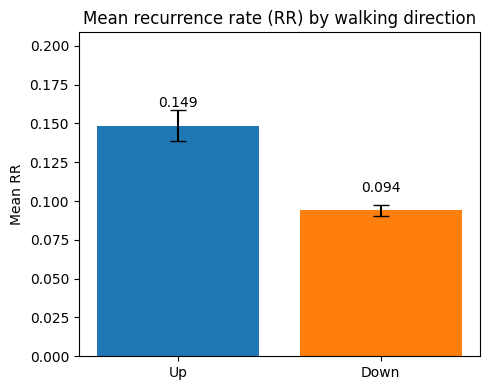

In [15]:
import matplotlib.pyplot as plt

# Group by walking direction and compute mean + SEM for RR
order = ["Up", "Down"]
rr_stats = (
    summary_df.groupby("walking_direction")["RR"]
    .agg(["mean", "sem", "count"])
    .reindex(order)
    .dropna()
    .reset_index()
)

# Plot bar chart with error bars for SEM
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    rr_stats["walking_direction"],
    rr_stats["mean"],
    yerr=rr_stats["sem"],
    capsize=6,
    color=["C0", "C1"],
)
ax.set_ylabel("Mean RR")
ax.set_title("Mean recurrence rate (RR) by walking direction")
ax.set_ylim(0, rr_stats["mean"].max() + (rr_stats["sem"].max() if not rr_stats["sem"].isnull().all() else 0) + 0.05)

# Annotate means
for i, v in enumerate(rr_stats["mean"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

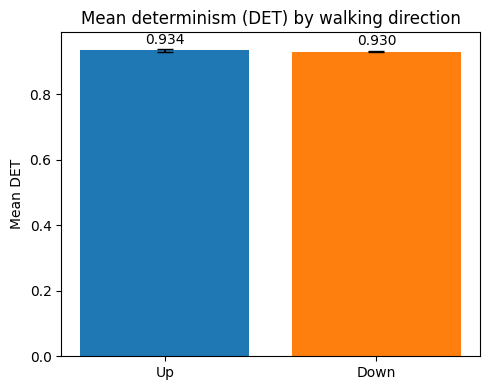

In [18]:
# Group by walking direction and compute mean + SEM for DET
order = ["Up", "Down"]
det_stats = (
    summary_df.groupby("walking_direction")["DET"]
    .agg(["mean", "sem", "count"])
    .reindex(order)
    .dropna()
    .reset_index()
)

# Plot bar chart with error bars for SEM
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(
    det_stats["walking_direction"],
    det_stats["mean"],
    yerr=det_stats["sem"],
    capsize=6,
    color=["C0", "C1"],
)
ax.set_ylabel("Mean DET")
ax.set_title("Mean determinism (DET) by walking direction")
ax.set_ylim(0, det_stats["mean"].max() + (det_stats["sem"].max() if not det_stats["sem"].isnull().all() else 0) + 0.05)

# Annotate means
for i, v in enumerate(det_stats["mean"]):
    ax.text(i, v + 0.01, f"{v:.3f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

In [16]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ipywidgets import Dropdown, FloatSlider, HBox, VBox
from IPython.display import display, clear_output

def build_recurrence_plot_widget(
    base_dir="walk_segmented_csvs",
    gaze_col="gaze angle [deg]"
):
    """
    Build an ipywidget UI to:
      - select a trial CSV from base_dir
      - choose epsilon (radius)
      - plot a square recurrence plot for the gaze time series
    """

    # -----------------------------
    # 1. Find CSV files
    # -----------------------------
    if not os.path.isdir(base_dir):
        raise FileNotFoundError(
            f"Directory '{base_dir}' not found. "
            "Make sure it exists and contains segmented trial CSVs."
        )

    csv_files = sorted(
        f for f in os.listdir(base_dir)
        if f.lower().endswith(".csv")
    )
    if not csv_files:
        raise RuntimeError(f"No CSV files found in '{base_dir}'.")

    # -----------------------------
    # 2. Create widgets
    # -----------------------------
    file_dropdown = Dropdown(
        options=csv_files,
        value=csv_files[0],
        description="Segment:",
        style={"description_width": "initial"},
        layout={"width": "400px"}
    )

    epsilon_slider = FloatSlider(
        value=2.0,         # default epsilon
        min=0.1,
        max=20.0,
        step=0.1,
        description="epsilon (deg):",
        style={"description_width": "initial"},
        readout_format=".2f",
        layout={"width": "400px"}
    )

    controls = HBox([file_dropdown, epsilon_slider])

    # -----------------------------
    # 3. Plotting logic
    # -----------------------------
    def update_plot(*_):
        fname = file_dropdown.value
        epsilon = float(epsilon_slider.value)

        fpath = os.path.join(base_dir, fname)

        clear_output(wait=True)
        display(VBox([controls]))

        df = pd.read_csv(fpath)

        if gaze_col not in df.columns:
            print(f"File '{fname}' is missing column '{gaze_col}'.")
            return

        gaze = df[gaze_col].to_numpy(dtype=float)

        # Drop NaNs (blinks) for the recurrence calculation
        mask = ~np.isnan(gaze)
        x = gaze[mask]

        if x.size < 2:
            print(f"Not enough valid gaze samples in '{fname}' after removing NaNs.")
            return

        # Build recurrence matrix: R[i,j] = 1 if |x_i - x_j| <= epsilon
        dist = np.abs(x[:, None] - x[None, :])
        R = dist <= epsilon
        N = x.size

        # Plot as a perfect square
        plt.figure(figsize=(6, 6))
        ax = plt.gca()
        im = ax.imshow(
            R,
            origin="lower",
            cmap="gray_r",
            interpolation="nearest",
            extent=[0, N - 1, 0, N - 1]  # same index range on x and y
        )

        ax.set_xlabel("Time index")
        ax.set_ylabel("Time index")
        ax.set_title(f"Recurrence plot\n{fname}\nε = {epsilon:.2f} deg")

        # Force square aspect: same scale for x and y
        ax.set_aspect("equal", "box")
        ax.set_xlim(0, N - 1)
        ax.set_ylim(0, N - 1)

        plt.tight_layout()
        plt.show()

    file_dropdown.observe(update_plot, names="value")
    epsilon_slider.observe(update_plot, names="value")

    display(VBox([controls]))
    update_plot()  # initial plot


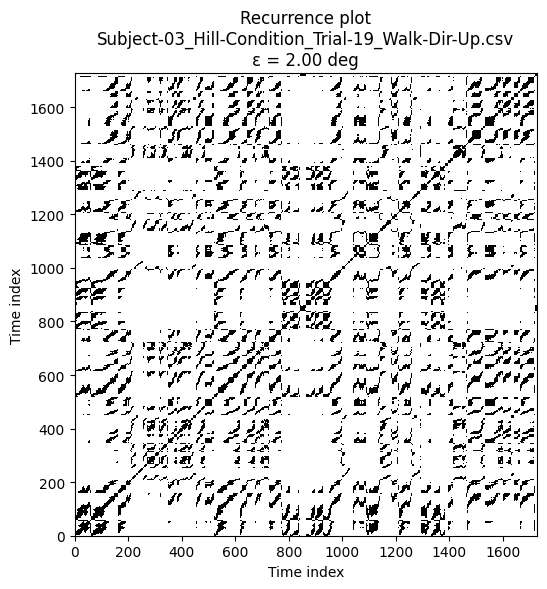

In [17]:

# In your notebook, call:
build_recurrence_plot_widget()